In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv('Diwali Sales Data.csv', encoding= 'unicode_escape')

In [3]:
df.shape

(11251, 15)

In [4]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [6]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [7]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [8]:
df.dropna( inplace=True)

In [9]:
df['Amount'] = df['Amount'].astype('int')

In [10]:
df['Amount'].dtypes

dtype('int32')

In [11]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [12]:
#rename column
df.rename(columns= {'Marital_Status':'Shaadi'})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Shaadi,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


In [13]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


# Exploratory Data Analysis

### Gender

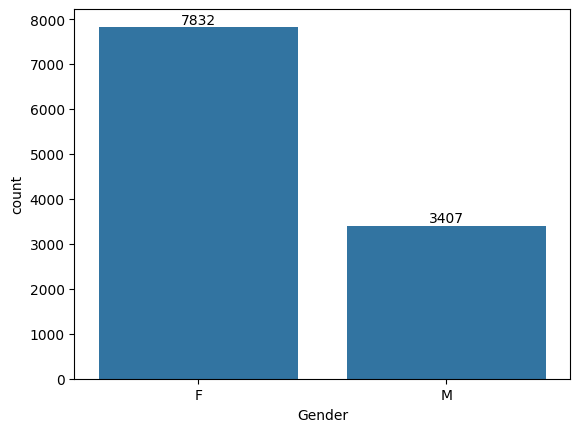

In [14]:
# plotting a bar chart for Gender and it's count

ax = sns.countplot(x = 'Gender',data = df)

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

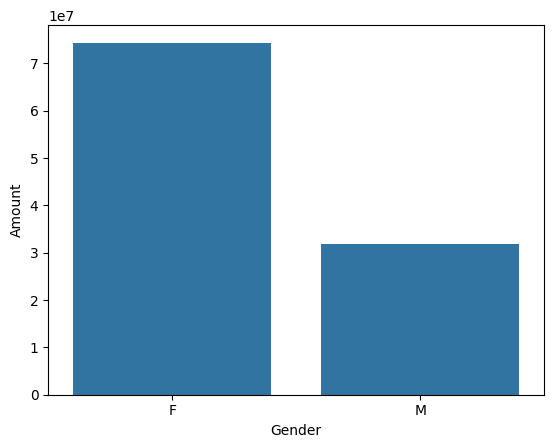

In [15]:
# plotting a bar chart for gender vs total amount

sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x = 'Gender',y= 'Amount' ,data = sales_gen)

*From above graphs we can see that most of the buyers are females and even the purchasing power of females are greater than men*

### Age

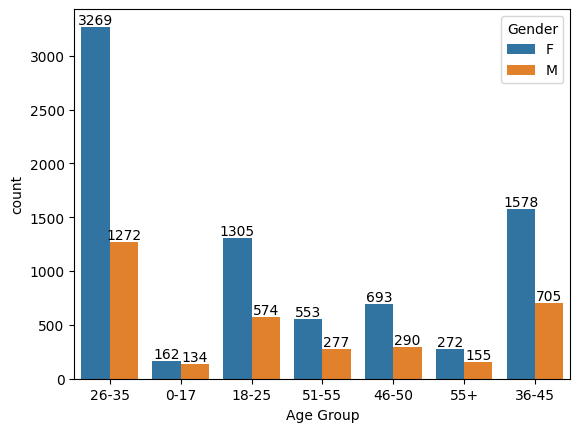

In [16]:
ax = sns.countplot(data = df, x = 'Age Group', hue = 'Gender')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: title={'center': 'Age wise spending'}, xlabel='Age Group', ylabel='Amount'>

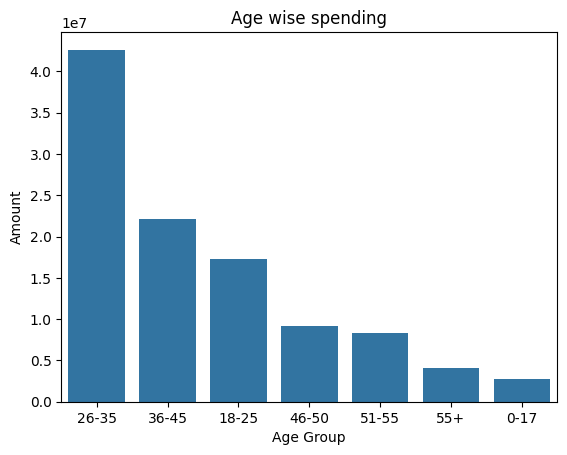

In [17]:
# Total Amount vs Age Group
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
plt.title("Age wise spending")
sns.barplot(x = 'Age Group',y= 'Amount' ,data = sales_age)

From above graphs we can see that most of the buyers are of age group between 26-35 yrs female

### State

Text(0.5, 1.0, 'State wise orders')

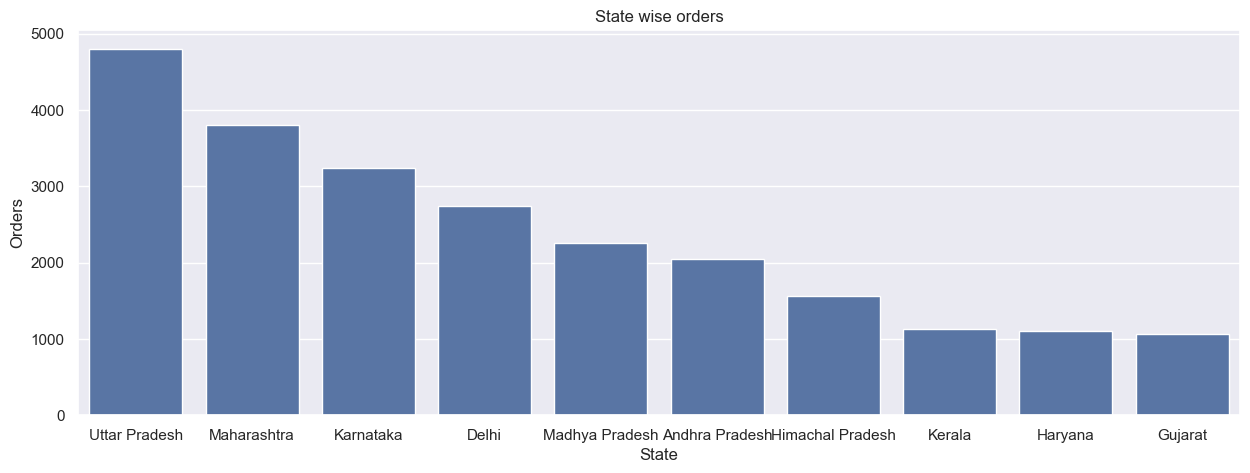

In [18]:
# total number of orders from top 10 states

sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State',y= 'Orders')
plt.title("State wise orders")

<Axes: xlabel='State', ylabel='Amount'>

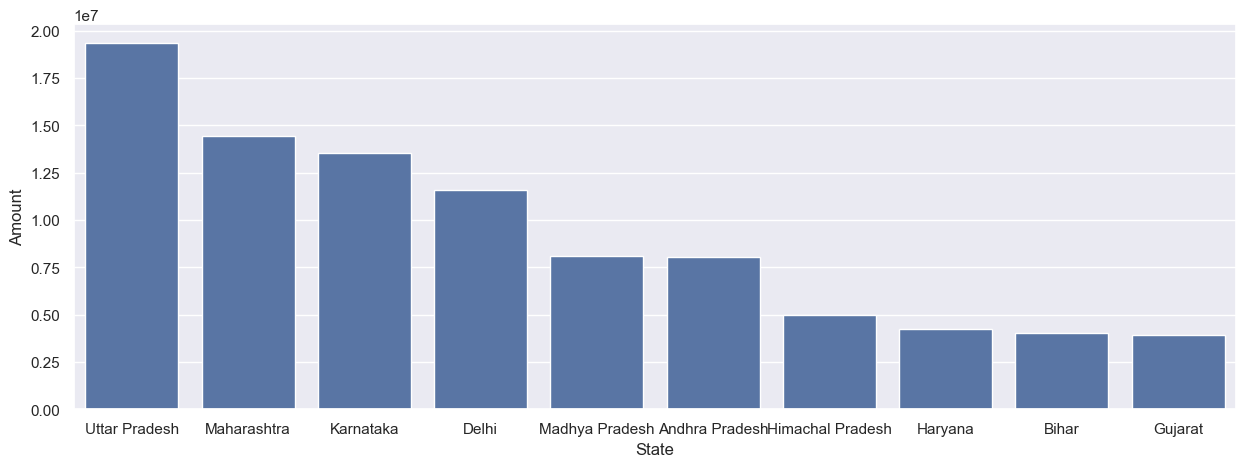

In [19]:
# total amount/sales from top 10 states

sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State',y= 'Amount')


*From above graphs we can see that most of the orders & total sales/amount are from Uttar Pradesh, Maharashtra and Karnataka respectively*


### Marital Status

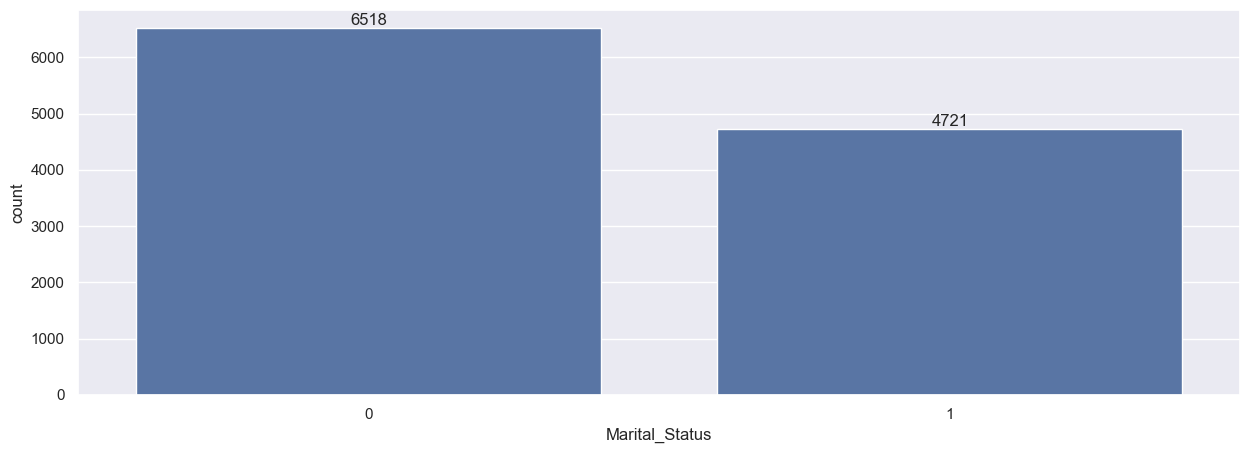

In [20]:
ax = sns.countplot(data = df, x = 'Marital_Status')

sns.set(rc={'figure.figsize':(7,4)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

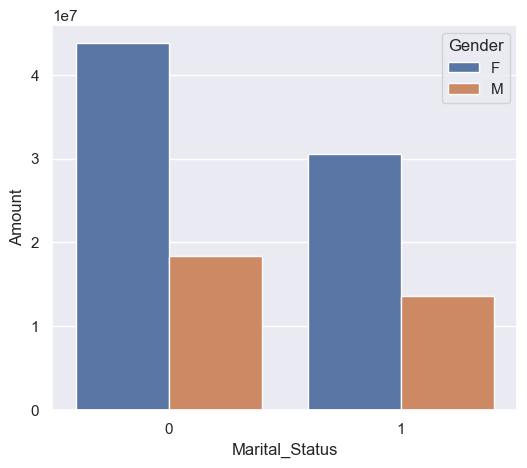

In [21]:
sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(data = sales_state, x = 'Marital_Status',y= 'Amount', hue='Gender')

*From above graphs we can see that most of the buyers are married (women) and they have high purchasing power*

### Occupation

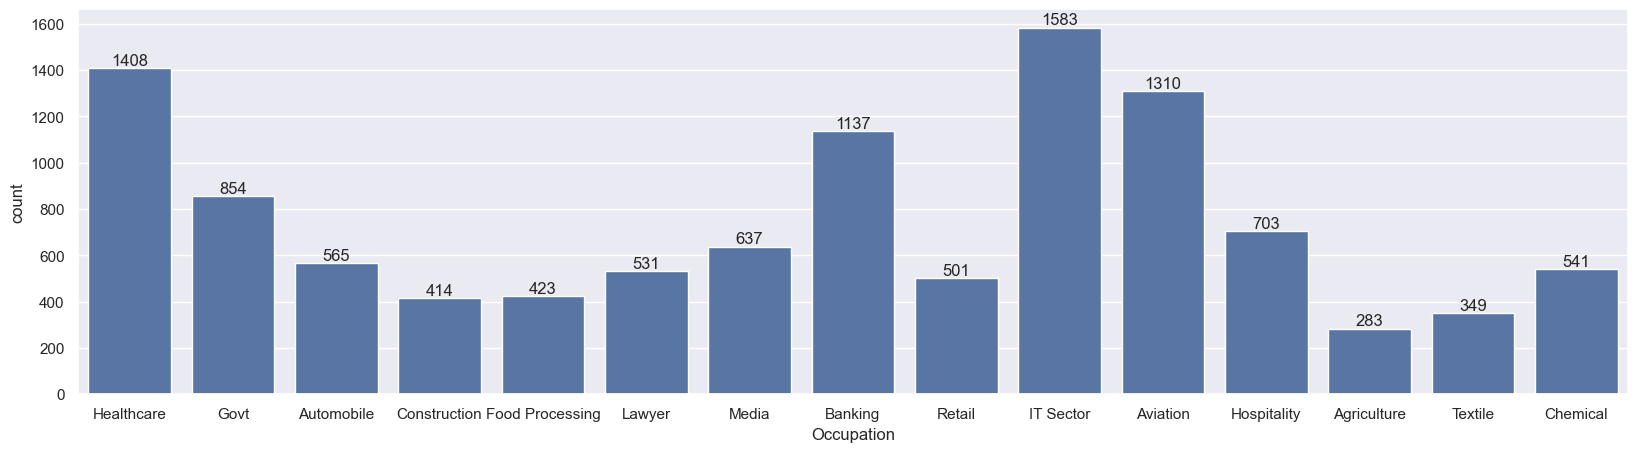

In [22]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Occupation')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: title={'center': 'Buyers working in different sectors'}, xlabel='Occupation', ylabel='Amount'>

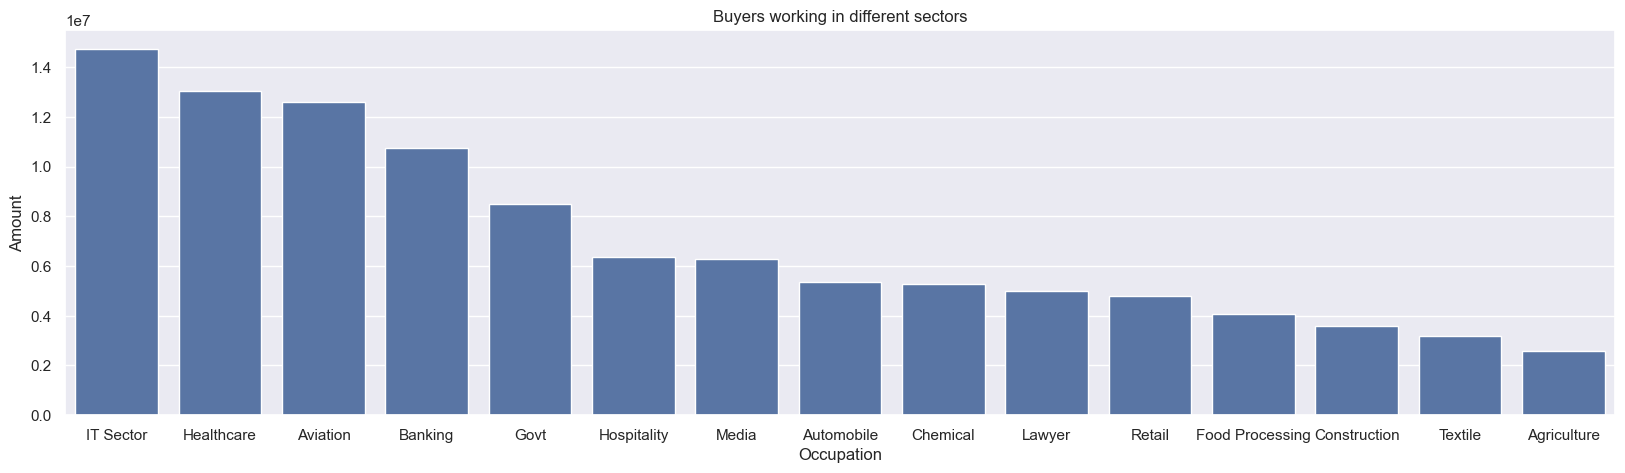

In [23]:
sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
plt.title("Buyers working in different sectors")
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount')

*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector*

### Product Category

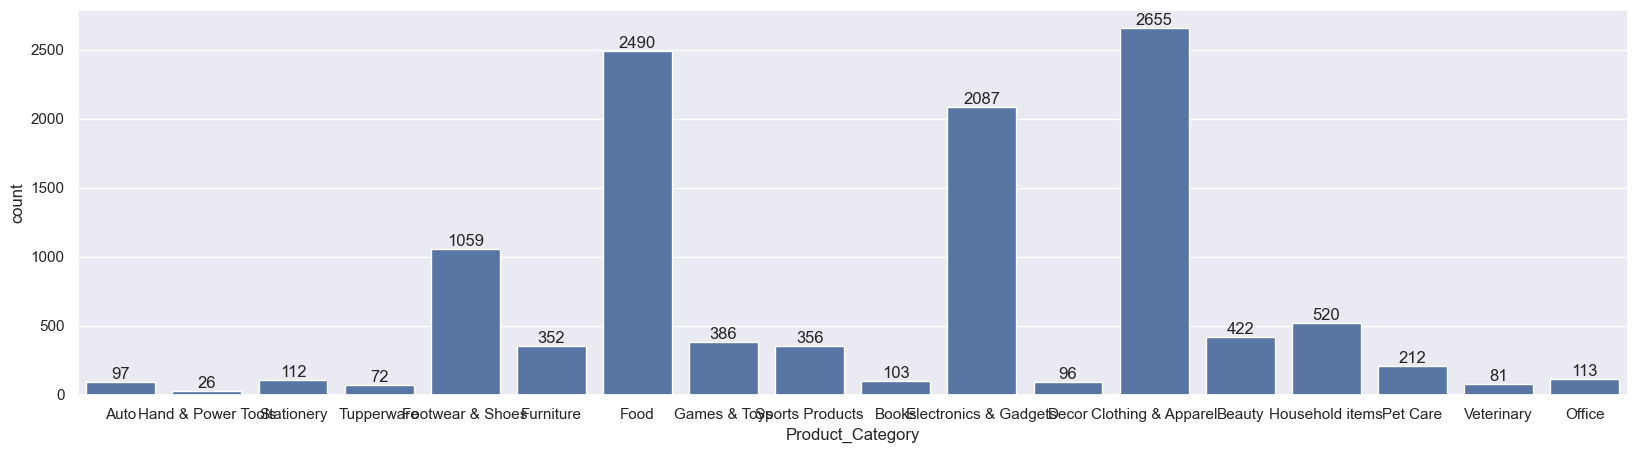

In [24]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Product_Category')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: title={'center': 'Top 10 selling products'}, xlabel='Product_Category', ylabel='Amount'>

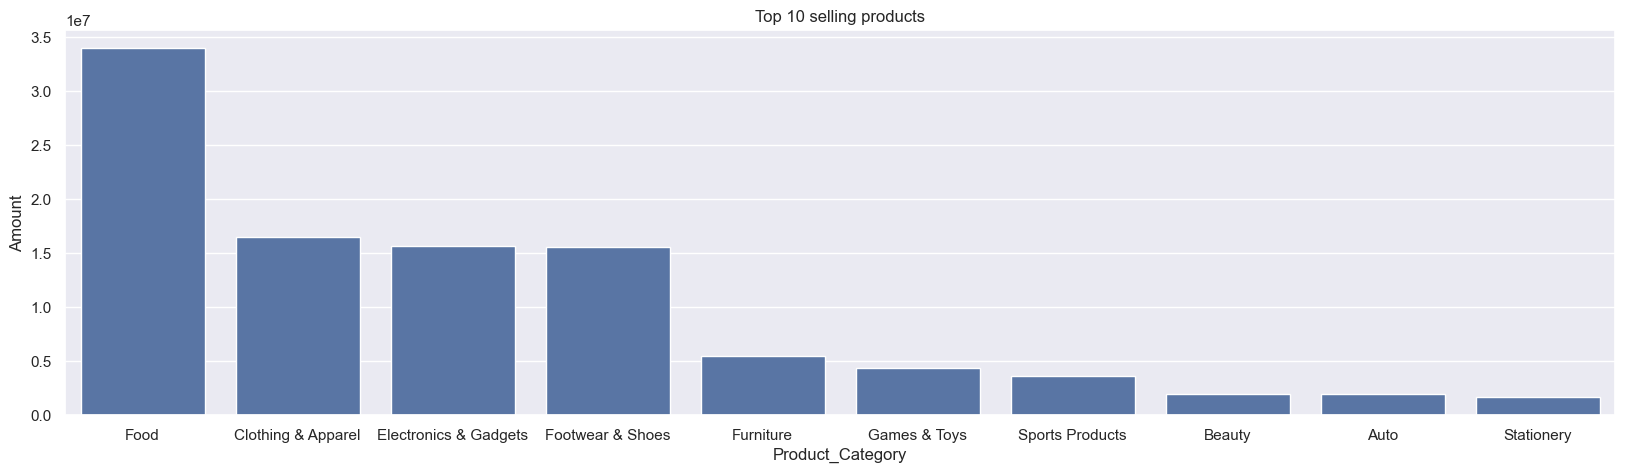

In [25]:
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)
plt.title("Top 10 selling products")
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount')

*From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category*

<Axes: xlabel='Product_ID', ylabel='Orders'>

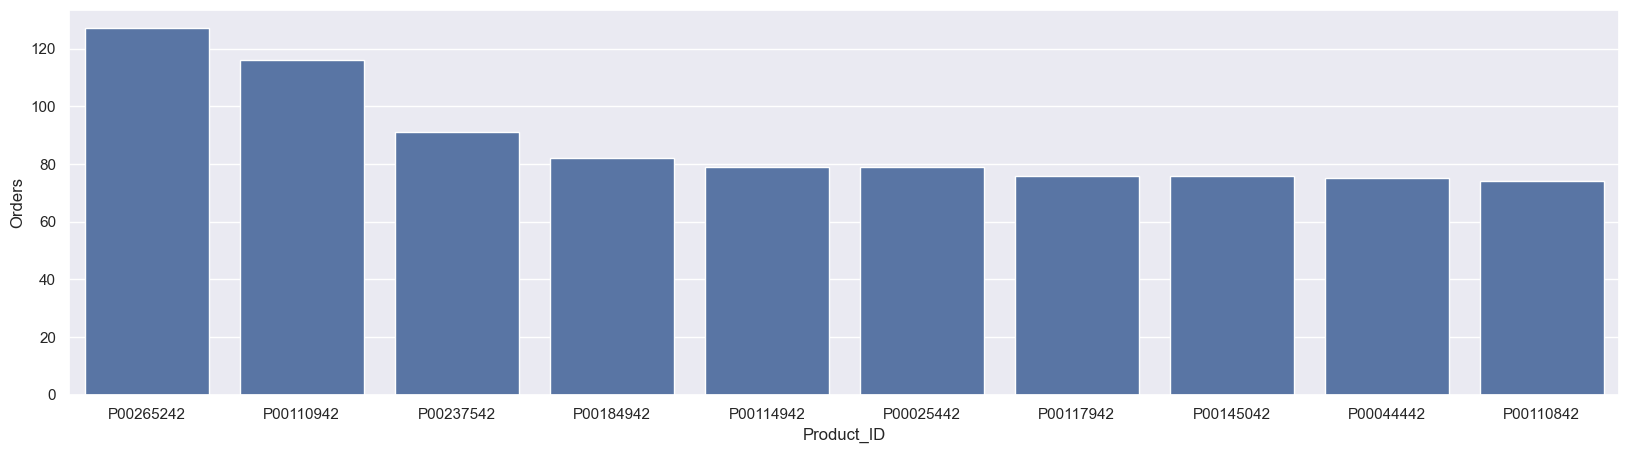

In [26]:
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_ID',y= 'Orders')

## Conclusion:


*Married women age group 26-35 yrs from UP,  Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category*

## Hypothesis Testing (A/B Testing)

1. Gender vs Amout (Independent t-test)

In [27]:
from scipy import stats

male_spend = df[df['Gender'] == 'M']['Amount']
female_spend = df[df['Gender'] == 'F']['Amount']
levene_stat, levene_p = stats.levene(male_spend, female_spend)

t_stat, p_value = stats.ttest_ind(male_spend, female_spend,equal_var=(levene_p > 0.05))

print(f"Levene's p-value: {levene_p:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Male avg spend: {male_spend.mean():.2f}")
print(f"Female avg spend: {female_spend.mean():.2f}")

Levene's p-value: 0.6682
T-statistic: -1.1600
P-value: 0.2461
Male avg spend: 9366.97
Female avg spend: 9491.30


*Result: p-value = 0.2461 (> 0.05) — not statistically significant. The ₹124 gap between male (₹9366.97) and female (₹9491.30) average spend is well within random variation. The higher total female spend seen in the EDA bar chart is driven by a larger number of female buyers, not a higher spend per person.*

2. Age Group vs Amount (One-way ANOVA)

In [29]:
age_groups = [group['Amount'].values for name, group in df.groupby('Age Group')]
f_stat, p_value = stats.f_oneway(*age_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 3.4149
P-value: 0.0023


In [31]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['Amount'], groups=df['Age Group'], alpha=0.05)
print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff p-adj    lower      upper   reject
----------------------------------------------------------
  0-17  18-25   55.0334    1.0  -907.3777 1017.4444  False
  0-17  26-35  263.7044 0.9805  -659.5187 1186.9275  False
  0-17  36-45  579.5042 0.5498  -371.2474 1530.2559  False
  0-17  46-50  246.6351 0.9919  -773.7236 1266.9938  False
  0-17  51-55  833.1374 0.2168  -208.7589 1875.0337  False
  0-17    55+  436.8973 0.9263  -727.0936 1600.8881  False
 18-25  26-35   208.671   0.77  -213.4807  630.8227  False
 18-25  36-45  524.4709 0.0214    45.0964 1003.8453   True
 18-25  46-50  191.6017 0.9674  -414.2061  797.4096  False
 18-25  51-55   778.104 0.0064   136.6844 1419.5237   True
 18-25    55+  381.8639 0.8206  -443.2094 1206.9372  False
 26-35  36-45  315.7999 0.2166   -79.0491  710.6488  False
 26-35  46-50  -17.0693    1.0  -558.4646  524.3261  False
 26-35  51-55   569.433  0.059    -11.536 1150.4021  Fal

*Result: ANOVA p-value = 0.0023 (< 0.05) — statistically significant, average spend does differ across age groups. The Tukey HSD post-hoc test shows this is driven specifically by the 18-25 group spending significantly less than 36-45 (p = 0.021) and 51-55 (p = 0.006). Every other pairwise comparison, including 26-35 vs. all other groups, is not statistically significant — meaning 26-35's high total spend in the EDA chart comes from having more buyers, not a higher average spend per buyer.*

3. Marital Status vs Gender (Chi-square test of independence)

In [33]:
contingency_table = pd.crosstab(df['Marital_Status'], df['Gender'])
print(contingency_table)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square statistic:{chi2:.4f}")
print(f"P-value:{p_value:.4f}")
print(f"Degrees of freedom:{dof}")

Gender             F     M
Marital_Status            
0               4573  1945
1               3259  1462

Chi-square statistic:1.5949
P-value:0.2066
Degrees of freedom:1


*Result: p-value = 0.2066 (> 0.05) not statistically significant. Marital Status and Gender are independent in this dataset. The "married women dominate" pattern in the EDA chart is a raw-count effect (more female buyers overall), not a real statistical relationship between being married and being female.*

## Conclusion

**Descriptive (EDA):** Married women, aged 26-35, from UP, Maharashtra and Karnataka, working in IT, Healthcare and Aviation, account for the highest **total** spend, mainly buying Food, Clothing and Electronics.

**Statistically validated (Hypothesis Testing):** Formal testing shows this total-spend pattern is driven largely by purchase **volume**, not per-person spend:
- Gender has **no significant effect** on average spend per buyer (p=0.246) — females simply outnumber male buyers.
- Marital status and gender are **statistically independent** (p=0.207) — the married-women pattern is a raw-count effect, not a real association.
- Age group **does** significantly affect average spend (p=0.0023) — but the effect is that **18-25 year-olds spend significantly less per transaction** than 36-45 and 51-55 year-olds (Tukey HSD), not that 26-35 is a standout high-spending group.

**Business takeaway:** Marketing spend aimed at maximizing *reach* (more buyers) can reasonably target the 26-35 / married-women segments seen in EDA, since that's where order volume concentrates. But campaigns aimed at increasing *spend per customer* should not assume gender or marital status move the needle — instead, the tested, defensible lever is age: 18-25 customers are the segment with measurably lower per-transaction spend and the clearest opportunity for a targeted upsell strategy.